In [10]:
!pip install yfinance

In [11]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Tata Steel ticker on NSE
ticker = "TATASTEEL.NS"
stock = yf.Ticker(ticker)

# Get split history
splits = stock.splits
print(splits)

Date
2004-08-11 00:00:00+05:30     1.5
2022-07-28 00:00:00+05:30    10.0
Name: Stock Splits, dtype: float64


In [12]:
# Get 5 years of price history
hist = stock.history(period="5y")
print(hist.tail())  # check it worked - should show recent prices

                                 Open        High         Low       Close  \
Date                                                                        
2026-09-07 00:00:00+05:30  189.000000  190.240005  184.369995  185.610001   
2026-09-08 00:00:00+05:30  185.899994  186.500000  183.610001  184.149994   
2026-09-09 00:00:00+05:30  184.800003  190.259995  183.410004  188.750000   
2026-09-10 00:00:00+05:30  189.000000  189.000000  185.000000  186.779999   
2026-09-11 00:00:00+05:30  184.000000  184.240005  180.789993  183.000000   

                             Volume  Dividends  Stock Splits  
Date                                                          
2026-09-07 00:00:00+05:30  23695657        0.0           0.0  
2026-09-08 00:00:00+05:30  24272812        0.0           0.0  
2026-09-09 00:00:00+05:30  45985325        0.0           0.0  
2026-09-10 00:00:00+05:30  23334612        0.0           0.0  
2026-09-11 00:00:00+05:30  31510206        0.0           0.0  


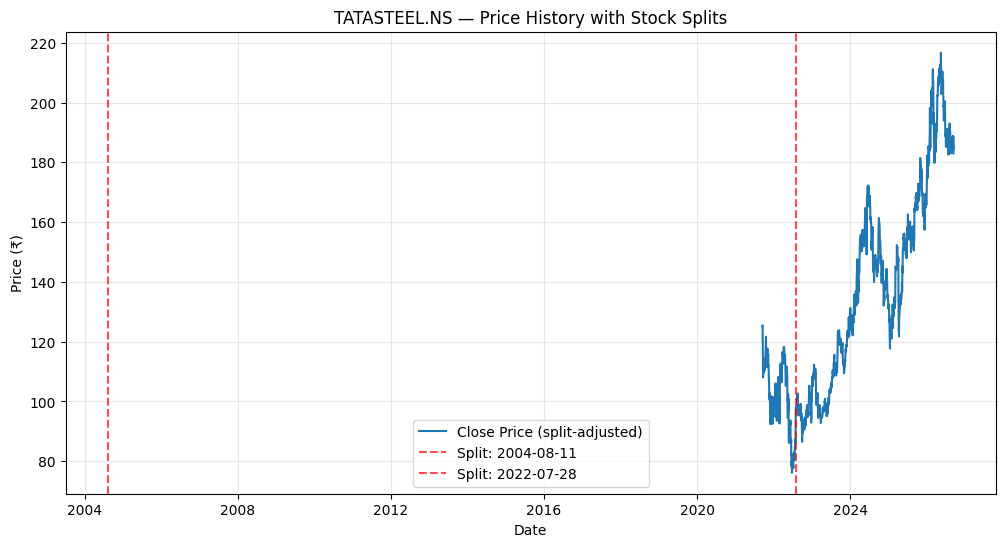

In [13]:
plt.figure(figsize=(12,6))
plt.plot(hist.index, hist['Close'], label='Close Price (split-adjusted)')

# Mark the split date(s) with a vertical line
for split_date in splits.index:
    plt.axvline(x=split_date, color='red', linestyle='--', alpha=0.7,
                label=f'Split: {split_date.date()}')

plt.title(f'{ticker} — Price History with Stock Splits')
plt.xlabel('Date')
plt.ylabel('Price (₹)')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('tata_steel_splits.png')
plt.show()